# Sales Analytics with DuckDB SQL

This notebook explores ecommerce sales performance using DuckDB, SQL, and Python visualizations.

Main business questions:
- What is the total revenue generated?
- Which product categories generate the highest revenue?
- How does revenue evolve over time?
- What trends can be identified using rolling averages?

Key topics:
- SQL aggregations
- Common Table Expressions (CTEs)
- Window functions
- Revenue trend analysis
- Time-series analytics
- Data visualization with Seaborn

In [7]:
##Imports
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
##Creating the connection
conn = duckdb.connect("../ecommerce.duckdb")

In [9]:
##Verifying tables
conn.execute("SHOW TABLES").df()

,name
0,dim_brands
1,dim_categories
2,dim_customers
3,dim_products
4,fact_order_items
5,orders


#### Sales Analytics

This notebook analyzes revenue trends, customer purchasing behavior, and category performance using DuckDB and SQL analytics.

#### Total Revenue

In [10]:
conn.execute("""
SELECT
    ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS total_revenue
FROM fact_order_items
""").df()

,total_revenue
0,25328210.62


#### Revenue by Category

In [11]:
category_revenue_df = conn.execute("""
SELECT
    c.category_name,
    ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
FROM fact_order_items f
JOIN dim_products p
    ON f.product_id = p.product_id
JOIN dim_categories c
    ON p.category_id = c.category_id
GROUP BY c.category_name
ORDER BY revenue DESC
""").df()

category_revenue_df

,category_name,revenue
0,Fashion,4417902.37
1,Toys,3991835.22
2,Sports,3861270.03
3,Beauty,3810279.02
4,Home,3286879.02
5,Electronics,3133656.59
6,Books,2826388.37


Electronics and Sports generate the highest revenue contribution across all categories.

#### Barplot

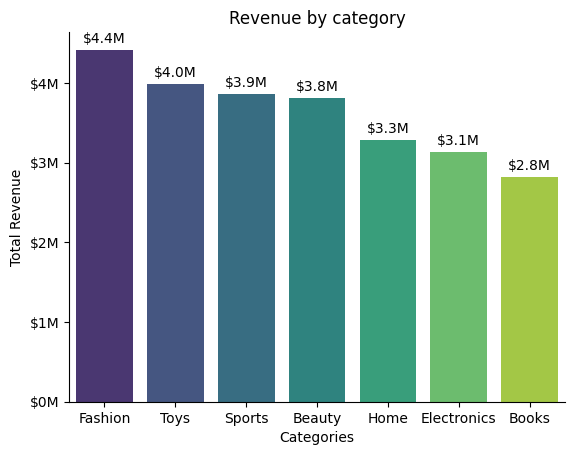

In [12]:
import matplotlib.ticker as ticker

ax =sns.barplot(data=category_revenue_df, x= "category_name", y= "revenue", hue="category_name",
                palette="viridis")
plt.xlabel("Categories")
plt.ylabel("Total Revenue")

for x in ax.containers:
    labels = [
        f'${v.get_height()/1_000_000:.1f}M'
        for v in x
    ]
    ax.bar_label(
        x,
        labels=labels,
        padding=3
    )

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'${x/1_000_000:.0f}M'
    )
)

plt.title("Revenue by category")
sns.despine()

plt.savefig(
    "../images/revenue_by_category.png",
    bbox_inches="tight"
)

plt.show()

#### Windows Functions & CTEs

In [13]:
conn.execute("""
WITH customer_revenue AS (
    SELECT
        o.customer_id, ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
    FROM fact_order_items f
    JOIN orders o
        ON f.order_id = o.order_id
    GROUP BY o.customer_id
)

SELECT
    customer_id,
    revenue,
    RANK() OVER(ORDER BY revenue DESC) AS customer_rank
FROM customer_revenue
ORDER BY revenue DESC
LIMIT 10
""").df()

,customer_id,revenue,customer_rank
0,433,71080.78,1
1,615,63983.17,2
2,465,61623.09,3
3,144,57346.73,4
4,711,53539.57,5
5,69,53041.77,6
6,945,52614.45,7
7,464,52027.78,8
8,303,51180.56,9
9,175,49986.19,10


#### Monthly Revenue Analysis

In [14]:
monthly_revenue_df = conn.execute("""
SELECT
    DATE_TRUNC('month', o.order_date) AS month, 
    ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
FROM fact_order_items f
JOIN orders o
    ON f.order_id = o.order_id
GROUP BY month
ORDER BY month
""").df()

monthly_revenue_df

,month,revenue
0,2024-05-01,512407.08
1,2024-06-01,1017577.85
2,2024-07-01,939018.09
3,2024-08-01,1152718.39
4,2024-09-01,1166110.22
5,2024-10-01,1070300.76
6,2024-11-01,1055902.13
7,2024-12-01,1181838.73
8,2025-01-01,1059338.86
9,2025-02-01,927510.44


#### Lineplot

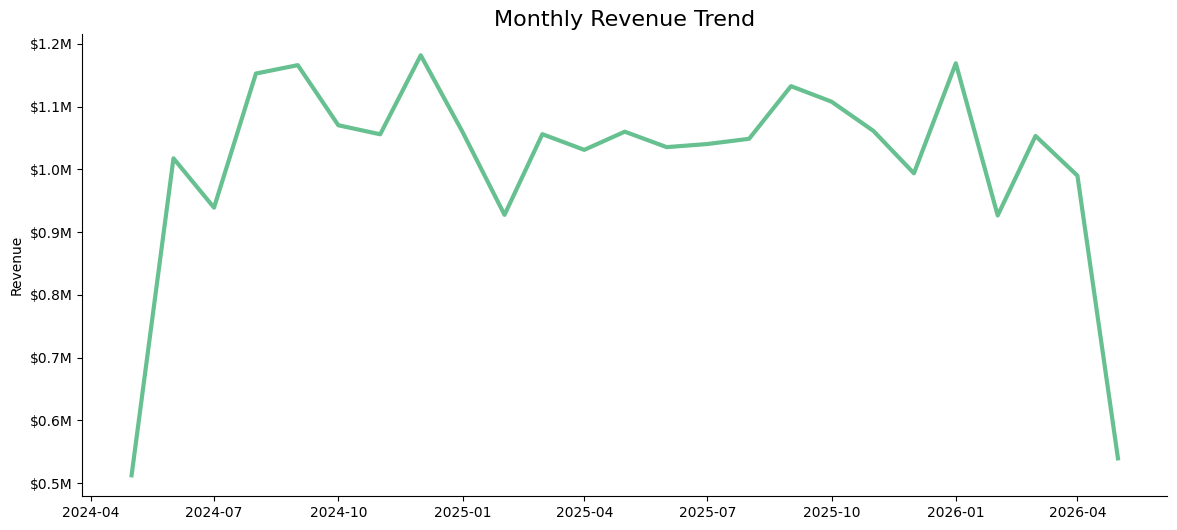

In [18]:
plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data=monthly_revenue_df,
    x="month",
    y="revenue",
    linewidth= 3, 
    color = "#67C090"
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'${x/1_000_000:.1f}M'
    )
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
)

plt.xlabel("")
plt.ylabel("Revenue")

sns.despine()

plt.savefig(
    "../images/monthly_revenue_trend.png",
    bbox_inches="tight"
)

plt.show()

#### Rolling Average (3 months)

In [16]:
rolling_revenue_df = conn.execute("""
WITH monthly_revenue AS (
    SELECT
        DATE_TRUNC('month', o.order_date) AS month,
        ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
    FROM fact_order_items f
    JOIN orders o
        ON f.order_id = o.order_id
    GROUP BY month
)

SELECT
    month,
    revenue,
    ROUND(AVG(revenue) OVER(ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS rolling_3m_avg

FROM monthly_revenue

ORDER BY month
""").df()

#### Dual Visualization

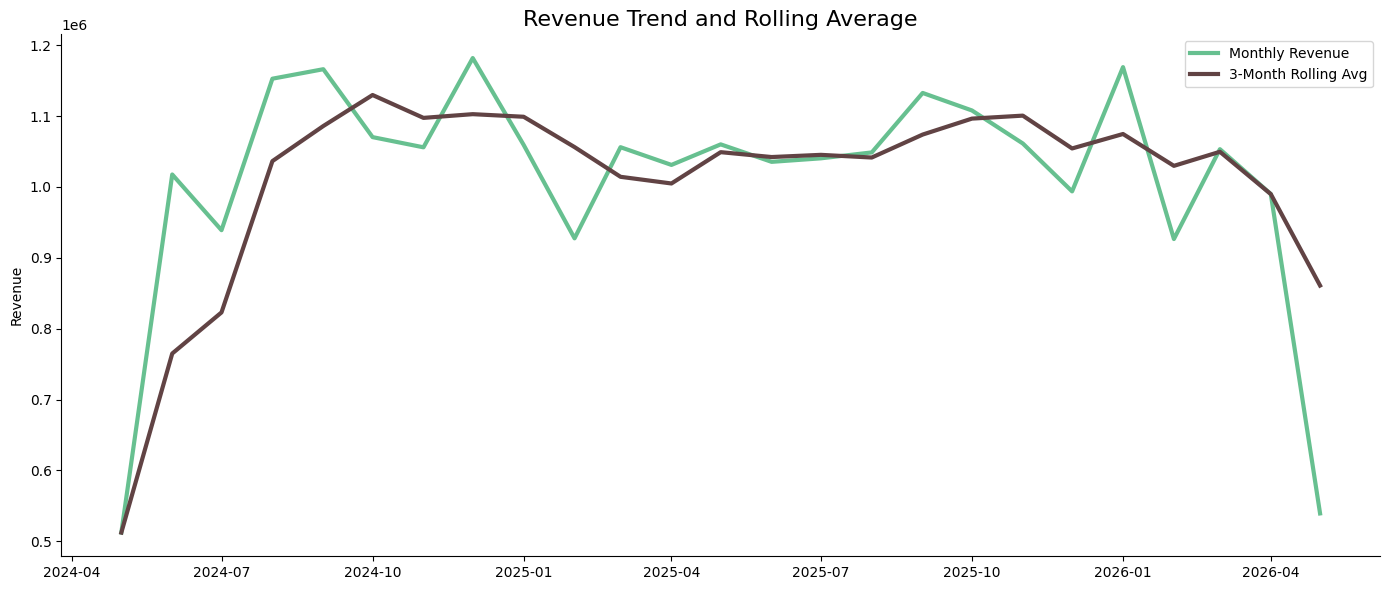

In [19]:
from turtle import color


plt.figure(figsize=(14,6))

sns.lineplot(
    data=rolling_revenue_df,
    x="month",
    y="revenue",
    label="Monthly Revenue",
    linewidth= 3,
    color="#67C090"
)

sns.lineplot(
    data=rolling_revenue_df,
    x="month",
    y="rolling_3m_avg",
    label="3-Month Rolling Avg",
    linewidth= 3, 
    color= "#614344"
)

plt.title(
    "Revenue Trend and Rolling Average",
    fontsize=16
)

plt.xlabel("")
plt.ylabel("Revenue")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/revenue_trend_and_rolling_average.png",
    bbox_inches="tight"
)

plt.show()